## IMPORTS


In [7]:
import pandas as pd
import numpy as np
import optuna
from sklearn.impute import SimpleImputer
import os
from imblearn.pipeline import Pipeline 
import xgboost as  xgb
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, precision_score
import sys
from sklearn.experimental import enable_iterative_imputer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import joblib
import logging
from sklearn.model_selection import train_test_split
import optuna
from sklearn.svm import SVC
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")
import optuna.visualization as ov
import optuna.visualization.matplotlib as ov  
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



ruta_raiz = os.path.abspath('..')
if ruta_raiz not in sys.path:
    sys.path.append(ruta_raiz)

%load_ext autoreload
%autoreload 2
from Data_preprocesing.IQRCapper import IQRCapper



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


LOS OUTPUTS DE OPTUNA QUE LOS IMPRIMA EN UN TXT PARA SIN VOLVERLO A CORRER

In [8]:
log_file = logging.FileHandler("optuna_resultados.txt")
log_file.setFormatter(logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s'))
optuna.logging.get_logger("optuna").addHandler(log_file)

## LOAD DATA + SAVE FUCTION


In [ ]:
X_train = pd.read_csv("../Train_test_split/X_train.csv")
y_train = pd.read_csv("../Train_test_split/y_train.csv")
X_test = pd.read_csv("../Train_test_split/X_test.csv")
y_test = pd.read_csv("../Train_test_split/y_test.csv")



target_folder = '../comparations'

def save_experiment(model_name, imbalance_method, accuracy, precision, recall, f1, roc_auc):
    new_result = {
        'Model': [model_name],
        'Imbalance_Method': [imbalance_method],
        'Accuracy': [round(accuracy, 4)],
        'Precision': [round(precision, 4)],
        'Recall': [round(recall, 4)],
        'F1_Score': [round(f1, 4)],
        'ROC_AUC': [round(roc_auc, 4)]
    }
    df_new = pd.DataFrame(new_result)
    
    # Point the file to inside the folder
    csv_file = f'{target_folder}/imbalance_results.csv'
    
    if os.path.exists(csv_file):
        df_new.to_csv(csv_file, mode='a', header=False, index=False)
    else:
        df_new.to_csv(csv_file, index=False)
        
    print(f"✅ Success! Results for {model_name} + {imbalance_method} saved in the '{target_folder}' folder.")


In [ ]:
num_classes = int(y_train['customer_segment'].nunique())
modelo_xgb = xgb.XGBClassifier(
    objective='multi:softmax', 
    num_class=num_classes, 
    random_state=42,
    eval_metric='mlogloss'
)

## STACKING CLASIFFIER

In [5]:
TRAINSTACK =True
CHOOSE_SAMPLER_STACK = True
CHARGE_STACKING = True
SAVE_MODEL_STACK = True

In [ ]:
imbalance_methods = {
    "Baseline": None,
    "RandomUnderSampler":     RandomUnderSampler(random_state=42),
    "TomekLinks":             TomekLinks(),
    "RandomOverSampler":      RandomOverSampler(random_state=42),
    "SMOTE":                  SMOTE(random_state=42),
    "ADASYN":                 ADASYN(random_state=42),
    "SMOTETomek":             SMOTETomek(random_state=42),
    "SMOTEENN":               SMOTEENN(random_state=42),
}


if CHOOSE_SAMPLER_STACK:
    best_sampler_name = None
    best_f1 = 0
    stacking = StackingClassifier(
        estimators=[
            ('xgb', xgb.XGBClassifier(num_classes =  int(y_train['customer_segment'].nunique()),random_state=42)),
            ('rf', RandomForestClassifier(random_state=42)),
            ('svm', SVC(probability=True, random_state=42)),
            ('lgbm', lgb.LGBMClassifier(random_state=42)),
        ],
        final_estimator=LogisticRegression(random_state=42),
        cv=3,
        stack_method='predict_proba',
        n_jobs=-1
    )
    for method_name, sampler in imbalance_methods.items():
        steps = [
            ('capping_outliers', IQRCapper(factor=1.5)),
            ('imputacion', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler()),
        ]
        if sampler is not None:
            steps.append(('sampler', sampler))
        steps.append(('classifier', stacking))

        pipe = Pipeline(steps)
        pipe.fit(X_train, y_train)

        y_pred = pipe.predict(X_test)
        y_proba = pipe.predict_proba(X_test)

        accuracy  = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

        print(f"Method: {method_name }: Accuracy: {accuracy:.4f} | F1: {f1:.4f} | ROC-AUC: {roc_auc:.4f}")

        """
        save_experiment(
            model_name="Stacking Clafier",
            imbalance_method=method_name,
            accuracy=accuracy,
            precision=precision,
            recall=recall,
            f1=f1,
            roc_auc=roc_auc
        )"""
        
        print(f"{method_name}: F1={f1:.4f}")
        if method_name == "Baseline": f1+=0.01   #Vamos a dar una pequeña ventaja a lo simple
        if f1 > best_f1:
            best_f1          = f1
            best_sampler_name = method_name
        
    print(f"\nMejor sampler: {best_sampler_name} (F1={best_f1:.4f})") 
best_sampler_name = "Baseline"

modelos_base = [
    ('xgb', xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=int(y_train['customer_segment'].nunique()),
        eval_metric='mlogloss',
        n_estimators=100,
        max_depth=4,
        tree_method='hist',
        random_state=42
    )),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )),
    ('svm', CalibratedClassifierCV(
        LinearSVC(random_state=42, max_iter=2000),
        cv=3
    )),
    ('lgb', lgb.LGBMClassifier(random_state=42, n_jobs=-1))
]

stacking_clf = StackingClassifier(
    estimators=modelos_base,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

best_sampler = imbalance_methods["Baseline"]

steps_final = [
    ('capping_outliers', IQRCapper(factor=1.5)),
    ('imputacion', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
]
if best_sampler is not None:
    steps_final.append(('sampler', best_sampler))
steps_final.append(('classifier', stacking_clf))

pipe_final = Pipeline(steps_final)
pipe_final.fit(X_train, y_train)

y_pred  = pipe_final.predict(X_test)
y_proba = pipe_final.predict_proba(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

print(f"\n--- Stacking Final ({best_sampler_name}) ---")
print(f"Accuracy: {accuracy:.4f} | F1: {f1:.4f} | ROC-AUC: {roc_auc:.4f}")



Method: Baseline: Accuracy: 0.7656 | F1: 0.7632 | ROC-AUC: 0.9063
Baseline: F1=0.7632
Method: RandomUnderSampler: Accuracy: 0.7398 | F1: 0.7432 | ROC-AUC: 0.9001
RandomUnderSampler: F1=0.7432


KeyboardInterrupt: 

In [ ]:
best_sampler = imbalance_methods["Baseline"]
#OLD VERSION WITH ALL HYPERPARAMETERS
if TRAINSTACK:
    def objective_stacking(trial):

        X_opt, _, y_opt, _ = train_test_split(
            X_train, y_train,
            train_size=25000,
            stratify=y_train,
            random_state=42
        )
        # META-MODELO: LogisticRegression
        solver = trial.suggest_categorical('meta_solver', ['saga', 'lbfgs'])
        penalty = trial.suggest_categorical('meta_penalty', ['l2', 'elasticnet']) if solver == 'saga' \
                else 'l2'  

        meta_model = LogisticRegression(
            C          = trial.suggest_float('meta_C', 1e-3, 10.0, log=True),
            penalty    = penalty,
            solver     = solver,
            l1_ratio   = trial.suggest_float('meta_l1_ratio', 0.0, 1.0)
                        if penalty == 'elasticnet' else None,
            max_iter   = trial.suggest_int('meta_max_iter', 500, 3000),
            tol        = trial.suggest_float('meta_tol', 1e-5, 1e-2, log=True),
            class_weight = trial.suggest_categorical('meta_class_weight', [None, 'balanced']),
            random_state = 42
        )

        # BASE LEARNER 1: XGBoost 
        xgb_model = xgb.XGBClassifier(
            n_estimators = trial.suggest_int('xgb_n_estimators', 50, 500),
            max_depth = trial.suggest_int('xgb_max_depth',3, 8),
            learning_rate = trial.suggest_float('xgb_learning_rate', 0.005, 0.3, log=True),
            subsample = trial.suggest_float('xgb_subsample', 0.5, 1.0),
            colsample_bytree = trial.suggest_float('xgb_colsample_bytree',0.5, 1.0),
            gamma = trial.suggest_float('xgb_gamma', 0.0, 5.0),
            reg_lambda = trial.suggest_float('xgb_lambda', 0.5, 10.0, log=True),
            reg_alpha = trial.suggest_float('xgb_alpha', 0.0, 5.0),
            min_child_weight = trial.suggest_int('xgb_min_child_weight', 1, 20),
            objective = 'multi:softprob',
            eval_metric = 'mlogloss',
            num_class = len(np.unique(y_train)),
            tree_method = 'hist',
            random_state = 42,
            n_jobs = -1
        )

        # BASE LEARNER 2: Random Forest
        rf_model = RandomForestClassifier(
            n_estimators = trial.suggest_int('rf_n_estimators', 50, 500),
            max_depth = trial.suggest_int('rf_max_depth', 3, 20),
            max_features = trial.suggest_float('rf_max_features', 0.3, 1.0),
            min_samples_split = trial.suggest_int('rf_min_samples_split', 2, 20),
            min_samples_leaf  = trial.suggest_int('rf_min_samples_leaf', 1, 10),
            random_state = 42,
            n_jobs = -1
        )

        # BASE LEARNER 3: SVM 
        svm_model = SVC(
            C = trial.suggest_float('svm_C', 1e-2, 100.0, log=True),
            gamma = trial.suggest_float('svm_gamma', 1e-4, 1.0, log=True),
            kernel = 'rbf',
            probability = True,
            random_state= 42
        )

        # BASE LEARNER 4: LightGBM 
        lgbm_model = lgb.LGBMClassifier(
            n_estimators  = trial.suggest_int('lgbm_n_estimators', 50, 500),
            max_depth = trial.suggest_int('lgbm_max_depth', 3, 8),
            learning_rate = trial.suggest_float('lgbm_learning_rate', 0.005, 0.3, log=True),
            num_leaves = trial.suggest_int('lgbm_num_leaves', 15, 127),
            subsample = trial.suggest_float('lgbm_subsample', 0.5, 1.0),
            colsample_bytree = trial.suggest_float('lgbm_colsample_bytree', 0.5, 1.0),
            reg_alpha = trial.suggest_float('lgbm_alpha', 0.0, 5.0),
            reg_lambda = trial.suggest_float('lgbm_lambda', 0.5, 10.0, log=True),
            objective = 'multiclass',
            random_state  = 42,
            n_jobs = -1,
            verbose = -1
        )

        # STACKING
        stacking = StackingClassifier(
            estimators=[
                ('xgb',xgb_model),
                ('rf', rf_model),
                ('svm',svm_model),
                ('lgbm', lgbm_model),
            ],
            final_estimator = meta_model,
            cv = 3,
            stack_method = 'predict_proba',
            n_jobs = -1
        )

        # PIPELINE
        steps = [
            ('capping_outliers', IQRCapper(factor=trial.suggest_float('iqr_factor', 1.0, 3.0))),
            ('imputacion', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler()),
        ]
        if best_sampler is not None:
            steps.append(('sampler', best_sampler))
        steps.append(('classifier', stacking))

        pipeline = Pipeline(steps)

        cv_splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        scores = cross_val_score(
            pipeline,
            X_opt, y_opt,       
            cv      = cv_splitter,
            scoring = 'roc_auc_ovr_weighted',
            n_jobs  = 1
        )

        return np.mean(scores)


# EJECUCIÓN 
if TRAINSTACK:
    best_value = [None]
    no_improve_count = [0]

    
    study = optuna.create_study(
        direction = "maximize",
        sampler = optuna.samplers.TPESampler(seed=42),
        pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=5)
    )
    
    def early_stopping_callback(study, trial):
        if best_value[0] is None or study.best_value > best_value[0]:
            best_value[0] = study.best_value
            no_improve_count[0] = 0
        else:
            no_improve_count[0] += 1
        if no_improve_count[0] >= 50:
            study.stop()


    study.optimize(
        objective_stacking,
        n_trials = 20,
        callbacks = [early_stopping_callback],
        show_progress_bar = True
    )
    
    joblib.dump(study, 'Studys/Stacking_study.pkl')

    print(f"\nMejor ROC-AUC (weighted OvR): {study.best_value:.4f}")
    print("Mejores hiperparámetros:")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")

    with open("mejores_parametros_Stacking.txt", "w") as f:
        f.write("Mejores hiperparámetros — Stacking Classifier\n")
        f.write("=" * 45 + "\n")
        for k, v in study.best_params.items():
            f.write(f"  {k}: {v}\n")

    print("\n¡Parámetros guardados en 'mejores_parametros_Stacking.txt'!")

[I 2026-03-19 22:08:43,239] A new study created in memory with name: no-name-71d57e14-5a28-4415-8ddb-6b538ee5fbc1
Best trial: 0. Best value: 0.903825:   2%|▏         | 1/60 [08:23<8:15:22, 503.78s/it]

[I 2026-03-19 22:17:07,024] Trial 0 finished with value: 0.903825454508425 and parameters: {'xgb_learning_rate': 0.023171758042400847, 'xgb_gamma': 4.75357153204958, 'xgb_lambda': 4.480392682684062, 'rf_n_estimators': 319, 'rf_min_samples_split': 4, 'lgbm_colsample_bytree': 0.5779972601681014, 'lgbm_alpha': 0.2904180608409973}. Best is trial 0 with value: 0.903825454508425.


Best trial: 1. Best value: 0.904561:   3%|▎         | 2/60 [12:42<5:47:44, 359.74s/it]

[I 2026-03-19 22:21:25,936] Trial 1 finished with value: 0.9045612736938167 and parameters: {'xgb_learning_rate': 0.1734451662584154, 'xgb_gamma': 3.005575058716044, 'xgb_lambda': 4.170553216181044, 'rf_n_estimators': 59, 'rf_min_samples_split': 20, 'lgbm_colsample_bytree': 0.9162213204002109, 'lgbm_alpha': 1.0616955533913808}. Best is trial 1 with value: 0.9045612736938167.


Best trial: 1. Best value: 0.904561:   5%|▌         | 3/60 [17:20<5:06:13, 322.34s/it]

...

[I 2026-03-20 01:53:39,256] Trial 45 finished with value: 0.9047270415395615 and parameters: {'xgb_learning_rate': 0.0896078519729284, 'xgb_gamma': 2.920523008960392, 'xgb_lambda': 3.4681217973034517, 'rf_n_estimators': 434, 'rf_min_samples_split': 16, 'lgbm_colsample_bytree': 0.7764688477483082, 'lgbm_alpha': 1.110287638402066}. Best is trial 27 with value: 0.9049053701589362.


Best trial: 27. Best value: 0.904905:  78%|███████▊  | 47/60 [3:49:24<58:31, 270.14s/it]  

[I 2026-03-20 01:58:07,482] Trial 46 finished with value: 0.9046691470126721 and parameters: {'xgb_learning_rate': 0.09091677134655617, 'xgb_gamma': 3.109721033751913, 'xgb_lambda': 3.429963298710634, 'rf_n_estimators': 464, 'rf_min_samples_split': 20, 'lgbm_colsample_bytree': 0.7849740677769167, 'lgbm_alpha': 1.0016980597871192}. Best is trial 27 with value: 0.9049053701589362.


Best trial: 27. Best value: 0.904905:  80%|████████  | 48/60 [3:54:07<58:31, 292.66s/it]

[I 2026-03-20 02:02:51,082] Trial 47 finished with value: 0.9041989910240568 and parameters: {'xgb_learning_rate': 0.04195902083500106, 'xgb_gamma': 2.6931053898222874, 'xgb_lambda': 2.2085776578619054, 'rf_n_estimators': 436, 'rf_min_samples_split': 16, 'lgbm_colsample_bytree': 0.854493457073622, 'lgbm_alpha': 0.3076678764209296}. Best is trial 27 with value: 0.9049053701589362.

Mejor ROC-AUC (weighted OvR): 0.9049
Mejores hiperparámetros:
  xgb_learning_rate: 0.20290493600385437
  xgb_gamma: 3.15232395608675
  xgb_lambda: 2.4490109645337004
  rf_n_estimators: 381
  rf_min_samples_split: 2
  lgbm_colsample_bytree: 0.5071969601466384
  lgbm_alpha: 0.7095379515151117

¡Parámetros guardados en 'mejores_parametros_Stacking.txt'!


In [ ]:
best_sampler = imbalance_methods["Baseline"]

# WITH ONLY IMPORTANT HYPERPARAMETERS

if TRAINSTACK:
    def objective_stacking(trial):

        X_opt, _, y_opt, _ = train_test_split(
            X_train, y_train,
            train_size=25000,
            stratify=y_train,
            random_state=42
        )

        # META-MODELO: parámetros fijos (baja importancia)
        meta_model = LogisticRegression(
            max_iter = 1000,
            random_state = 42
        )

        # BASE LEARNER 1: XGBoost 
        xgb_model = xgb.XGBClassifier(
            learning_rate = trial.suggest_float('xgb_learning_rate', 0.005, 0.3, log=True),
            gamma = trial.suggest_float('xgb_gamma', 0.0, 5.0),
            reg_lambda = trial.suggest_float('xgb_lambda', 0.5, 10.0, log=True),
            objective = 'multi:softprob',
            eval_metric = 'mlogloss',
            num_class = len(np.unique(y_train)),
            tree_method = 'hist',
            random_state = 42,
            n_jobs = -1
        )

        # BASE LEARNER 2: Random Forest
        rf_model = RandomForestClassifier(
            n_estimators = trial.suggest_int('rf_n_estimators', 50, 500),
            min_samples_split= trial.suggest_int('rf_min_samples_split', 2, 20),
            random_state = 42,
            n_jobs = -1
        )

        # BASE LEARNER 3: SVM 
        svm_model = SVC(
            gamma = 'scale',
            kernel = 'rbf',
            probability = True,
            random_state= 42
        )

        # BASE LEARNER 4: LightGBM 
        lgbm_model = lgb.LGBMClassifier(
            colsample_bytree = trial.suggest_float('lgbm_colsample_bytree', 0.5, 1.0),
            reg_alpha = trial.suggest_float('lgbm_alpha', 0.0, 5.0),
            objective = 'multiclass',
            random_state     = 42,
            n_jobs           = -1,
            verbose          = -1
        )

        # STACKING 
        stacking = StackingClassifier(
            estimators=[
                ('xgb', xgb_model),
                ('rf', rf_model),
                ('svm', svm_model),
                ('lgbm', lgbm_model),
            ],
            final_estimator = meta_model,
            cv = 3,
            stack_method = 'predict_proba',
            n_jobs = -1
        )

        # PIPELINE
        steps = [
            ('capping_outliers', IQRCapper(factor=1.5)),          
            ('imputacion', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler()),
        ]
        if best_sampler is not None:
            steps.append(('sampler', best_sampler))
        steps.append(('classifier', stacking))

        pipeline = Pipeline(steps)

        cv_splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        scores = cross_val_score(
            pipeline,
            X_opt, y_opt,
            cv = cv_splitter,
            scoring = 'roc_auc_ovr_weighted',
            n_jobs  = 1
        )

        return np.mean(scores)


# EJECUCIÓN 
if TRAINSTACK:
    best_value = [None]
    no_improve_count = [0]

    study = optuna.create_study(
        direction = "maximize",
        sampler = optuna.samplers.TPESampler(seed=42),
        pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)
    )

    def early_stopping_callback(study, trial):
        if best_value[0] is None or study.best_value > best_value[0]:
            best_value[0]      = study.best_value
            no_improve_count[0] = 0
        else:
            no_improve_count[0] += 1
        if no_improve_count[0] >= 20:        
            study.stop()

    study.optimize(
        objective_stacking,
        n_trials = 60,   
        callbacks = [early_stopping_callback],
        show_progress_bar = True
    )

    joblib.dump(study, 'Studys/Stacking_study.pkl')

    print(f"\Better ROC-AUC (weighted OvR): {study.best_value:.4f}")
    print("Best hyperparameter:")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")

    with open("mejores_parametros_Stacking.txt", "w") as f:
        f.write("Best hyperparameters")
        f.write("=" * 50 + "\n")
        for k, v in study.best_params.items():
            f.write(f"  {k}: {v}\n")

    print("Hyperparameters saved in'mejores_parametros_Stacking.txt'!")

In [4]:
study= joblib.load("Studys/Stacking_study.pkl")

print(study.best_params)

{'xgb_learning_rate': 0.20290493600385437, 'xgb_gamma': 3.15232395608675, 'xgb_lambda': 2.4490109645337004, 'rf_n_estimators': 381, 'rf_min_samples_split': 2, 'lgbm_colsample_bytree': 0.5071969601466384, 'lgbm_alpha': 0.7095379515151117}


In [6]:
study= joblib.load("Studys/Stacking_study.pkl")
if TRAINSTACK:
    ov.plot_param_importances(study)
    plt.title("Stacking - Parameter Importances") # Opcional: añadir título
    plt.tight_layout()
    plt.savefig("Graphs/TrainStack_param_importances.png")
    plt.close()
    ov.plot_optimization_history(study)
    plt.title("Stacking - Optimization History")
    plt.tight_layout()
    plt.savefig("Graphs/TrainStack_optimization_history.png")
    plt.close()
    ov.plot_slice(study)
    plt.tight_layout()
    plt.savefig("Graphs/TrainStack_slice.png")
    plt.close()
    


In [ ]:
if SAVE_MODEL_STACK:
    print("Reconstructing...")

    best = study.best_params

    # ─META-MODELO
    meta_model = LogisticRegression(C=best['meta_C'], max_iter=1000, random_state=42)

    # ── BASE LEARNER 1: XGBoost ──────────────────────────────────────
    xgb_model = xgb.XGBClassifier(
        n_estimators = best['xgb_n_estimators'],
        max_depth = best['xgb_max_depth'],
        learning_rate = best['xgb_learning_rate'],
        subsample = best['xgb_subsample'],
        colsample_bytree = best['xgb_colsample_bytree'],
        gamma = best['xgb_gamma'],
        reg_lambda = best['xgb_lambda'],
        reg_alpha = best['xgb_alpha'],
        min_child_weight = best['xgb_min_child_weight'],
        objective = 'multi:softprob',
        eval_metric = 'mlogloss',
        num_class = len(np.unique(y_train)),
        tree_method = 'hist',
        random_state = 42,
        n_jobs  = -1
    )

    # BASE LEARNER 2: Random Forest 
    rf_model = RandomForestClassifier(
        n_estimators = best['rf_n_estimators'],
        max_depth = best['rf_max_depth'],
        max_features = best['rf_max_features'],
        min_samples_split = best['rf_min_samples_split'],
        min_samples_leaf = best['rf_min_samples_leaf'],
        random_state = 42,
        n_jobs= -1
    )

    # BASE LEARNER 3: SVM 
    svm_model = SVC(
        C = best['svm_C'],
        gamma = best['svm_gamma'],
        kernel = 'rbf',
        probability = True,
        random_state = 42
    )

    # BASE LEARNER 4: LightGBM
    lgbm_model = lgb.LGBMClassifier(
        n_estimators = best['lgbm_n_estimators'],
        max_depth = best['lgbm_max_depth'],
        learning_rate = best['lgbm_learning_rate'],
        num_leaves = best['lgbm_num_leaves'],
        subsample = best['lgbm_subsample'],
        colsample_bytree = best['lgbm_colsample_bytree'],
        reg_alpha = best['lgbm_alpha'],
        reg_lambda = best['lgbm_lambda'],
        objective = 'multiclass',
        random_state = 42,
        n_jobs = -1,
        verbose = -1
    )

    # STACKING 
    stacking_final = StackingClassifier(
        estimators=[
            ('xgb', xgb_model),
            ('rf', rf_model),
            ('svm', svm_model),
            ('lgbm', lgbm_model),
        ],
        final_estimator = meta_model,
        cv = 5,
        stack_method = 'predict_proba',
        n_jobs = -1
    )

    # PIPELINE FINAL
    steps_final = [
        ('capping_outliers', IQRCapper(factor=best['iqr_factor'])),
        ('imputacion', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
    ]
    if best_sampler is not None:
        steps_final.append(('sampler', best_sampler))
    steps_final.append(('classifier', stacking_final))

    pipeline_final = Pipeline(steps_final)

    pipeline_final.fit(X_train, y_train)

    joblib.dump(pipeline_final, 'Modelos/modelo_stacking_ganador.pkl')
    print("Final model successfully trained and saved as 'modelo_stacking_ganador.pkl'!")

In [46]:
if CHARGE_STACKING:
    pipeline_final = joblib.load('Modelos/modelo_stacking_ganador.pkl')

    X_train = pd.read_csv("../Train_test_split/X_train.csv")
    y_train = pd.read_csv("../Train_test_split/y_train.csv")
    X_test = pd.read_csv("../Train_test_split/X_test.csv")
    y_test = pd.read_csv("../Train_test_split/y_test.csv")
    
    y_pred = pipeline_final.predict(X_test)
    y_pred_proba = pipeline_final.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba,
                              multi_class='ovr',
                              average='weighted')

    new_result = {
        'Model': ["Stacking Classifier"],
        'Imbalance_Method': [best_sampler_name],
        'Accuracy': [round(accuracy,  4)],
        'Precision': [round(precision, 4)],
        'Recall': [round(recall,    4)],
        'F1_Score': [round(f1,        4)],
        'ROC_AUC': [round(roc_auc,   4)]
    }

    print(new_result)

{'Model': ['Stacking Classifier'], 'Imbalance_Method': ['Baseline'], 'Accuracy': [0.7639], 'Precision': [0.7624], 'Recall': [0.7639], 'F1_Score': [0.7619], 'ROC_AUC': [0.9078]}


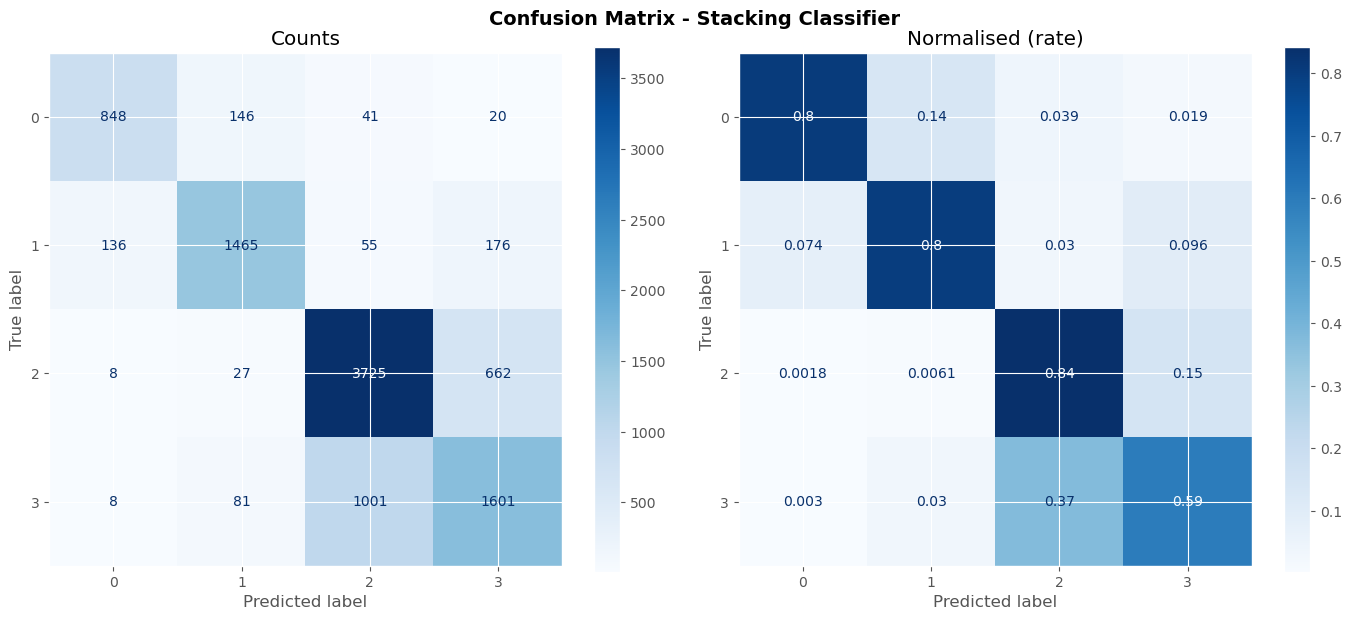

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Counts')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize='true')).plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Normalised (rate)')

plt.suptitle('Confusion Matrix - Stacking Classifier', fontsize=14, fontweight='bold')
plt.tight_layout()

# Guardar el gráfico
os.makedirs('Graphs', exist_ok=True)
plt.savefig('Graphs/StackingClassifier_confusionMatrix.png', dpi=150, bbox_inches='tight')

plt.show()